**Analysis Goal:** Clean a comprehensive global energy dataset and analyze the structural velocity of the shift from fossil fuels to renewables using grid percentages and correlation testing.

**Workflow:** 1. Full-Dataset Cleaning ➔ 2. Grid Percentage Normalization ➔ 3. Yearly Trend Aggregation ➔ 4. Statistical Correlation Test

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anshtanwar/global-data-on-sustainable-energy/global-data-on-sustainable-energy (1).csv


In [2]:
# Using the path copied from the output above
df = pd.read_csv('/kaggle/input/datasets/anshtanwar/global-data-on-sustainable-energy/global-data-on-sustainable-energy (1).csv')

df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

# Data Cleaning

**Resolving Column Name Issues**  
After running the initial info(), I realised that the density column is wrongly labelled as object. But when I attempted to access the density column, Python returned a KeyError, indicating that the column name was not recognized despite being visible in the summary.

The Diagnosis: I suspected hidden characters or trailing spaces in the CSV headers, which is a common data entry error.

The Solution: I will list the raw column names to identify the real columns names.

In [4]:
print(df.columns.tolist())

['Entity', 'Year', 'Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Financial flows to developing countries (US $)', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Primary energy consumption per capita (kWh/person)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Value_co2_emissions_kt_by_country', 'Renewables (% equivalent primary energy)', 'gdp_growth', 'gdp_per_capita', 'Density\\n(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']


Takeaway: The real density column name have an extra backslash.

## Data Type Conversion

Next up, let's examine the unique value in the density column to see exactly how the data is formatted. 

In [5]:
# Checking the first 10 unique values in that density column (object)
print(df['Density\\n(P/Km2)'].unique()[:10])

['60' '105' '18' '26' '223' '17' '104' '590' '3' '109']


Upon inspection, it appeared that the density column stores its value as Strings (text) eg. '60' '105'. Therefore, I am converting it from an Object (string) to a Float (numeric) to allow for mathematical analysis.

In [6]:
# Convert the column to a numeric type
df['Density\\n(P/Km2)'] = pd.to_numeric(df['Density\\n(P/Km2)'], errors='coerce')

# Verify the change
print(df['Density\\n(P/Km2)'].dtype)

float64


In [7]:
#verify density column can perform calculations
df['Density\\n(P/Km2)'].mean()

np.float64(141.03048264182897)

In [8]:
#verify density column can perform calculations
df['Density\\n(P/Km2)'].max()

1281.0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

## Missing Data (Null Analysis)
Before proceeding to analysis, I identified missing values, which is crucial because high percentages of null data can skew statistical results or cause errors in visualization.

In [10]:
# A quick count of how many holes are in each column
df.isnull().sum()

Entity                                                                 0
Year                                                                   0
Access to electricity (% of population)                               10
Access to clean fuels for cooking                                    169
Renewable-electricity-generating-capacity-per-capita                 931
Financial flows to developing countries (US $)                      2089
Renewable energy share in the total final energy consumption (%)     194
Electricity from fossil fuels (TWh)                                   21
Electricity from nuclear (TWh)                                       126
Electricity from renewables (TWh)                                     21
Low-carbon electricity (% electricity)                                42
Primary energy consumption per capita (kWh/person)                     0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          207
Value_co2_emissions_kt_by_country                  

In [11]:
# This shows the percentage of missing data for each column
df.isnull().mean() * 100

Entity                                                               0.000000
Year                                                                 0.000000
Access to electricity (% of population)                              0.274048
Access to clean fuels for cooking                                    4.631406
Renewable-electricity-generating-capacity-per-capita                25.513839
Financial flows to developing countries (US $)                      57.248561
Renewable energy share in the total final energy consumption (%)     5.316525
Electricity from fossil fuels (TWh)                                  0.575500
Electricity from nuclear (TWh)                                       3.453001
Electricity from renewables (TWh)                                    0.575500
Low-carbon electricity (% electricity)                               1.151000
Primary energy consumption per capita (kWh/person)                   0.000000
Energy intensity level of primary energy (MJ/$2017 PPP GDP)     

During the percentage check, I identified two columns with over 50% missing data:

1. Financial flow to developing countries (US $)
2. Renewables (% equivalent primary energy)

Strategy: Because more than half of the data is missing, imputation (filling) would likely introduce significant bias. For this specific analysis, I will drop these columns to ensure the remaining model relies on high-quality, verified data points.

In [12]:
# Dropping columns that have too much missing data to be reliable
cols_to_drop = ['Financial flows to developing countries (US $)', 'Renewables (% equivalent primary energy)']

# Axis=1 is used to tell Pandas to look at columns, not rows
df = df.drop(columns=cols_to_drop)

print(df.columns.tolist())

['Entity', 'Year', 'Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Primary energy consumption per capita (kWh/person)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Value_co2_emissions_kt_by_country', 'gdp_growth', 'gdp_per_capita', 'Density\\n(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']


Before moving to the final charts, the earlier check revealed that the **Renewable-electricity-generating-capacity-per-capita** column also had a major data gap, with roughly **25% of its values missing (null)**. 

To determine how to handle this gap, lets see exactly *which* years contained the most missing data:

In [13]:
# Check which years have the most nulls for this column
print(df[df['Renewable-electricity-generating-capacity-per-capita'].isnull()]['Year'].value_counts().sort_index())

Year
2000    43
2001    43
2002    43
2003    43
2004    43
2005    43
2006    43
2007    45
2008    45
2009    45
2010    45
2011    45
2012    45
2013    45
2014    45
2015    45
2016    45
2017    45
2018    45
2019    45
2020    45
Name: count, dtype: int64


It is revealed that null values for Renewable-electricity-generating-capacity-per-capita are distributed almost equally across the 2000–2006 (43 nulls) and 2007–2020 (45 nulls) periods.

The Verdict: DROP.  
Reasoning: Because the missing data is not isolated to a specific historical block, any attempt to fill these gaps would introduce artificial trends across the entire 20-year study period. To maintain the highest level of data integrity for my analysis, I will rely on more complete energy metrics.

In [14]:
# Dropping the per-capita column due to modern data gaps
df = df.drop(columns=['Renewable-electricity-generating-capacity-per-capita'])

In [15]:
# Final check for any remaining nulls across the whole dataframe
df.isnull().mean() * 100

Entity                                                               0.000000
Year                                                                 0.000000
Access to electricity (% of population)                              0.274048
Access to clean fuels for cooking                                    4.631406
Renewable energy share in the total final energy consumption (%)     5.316525
Electricity from fossil fuels (TWh)                                  0.575500
Electricity from nuclear (TWh)                                       3.453001
Electricity from renewables (TWh)                                    0.575500
Low-carbon electricity (% electricity)                               1.151000
Primary energy consumption per capita (kWh/person)                   0.000000
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          5.672787
Value_co2_emissions_kt_by_country                                   11.729241
gdp_growth                                                      

## Duplicate Detection
Before moving to EDA, I am performing a final check for duplicate records. 

**Rationale:** Duplicate rows can lead to incorrect conclusions. This check is performed *after* column dropping to ensure that no redundant rows were created by removing unique identifiers.

In [16]:
df.duplicated().sum()

np.int64(0)

# Data Analysis

Main question: How much did fossil fuel consumption change compared to renewable consumption between 2000 and 2020 globally? 

## Countries Grid Percentages  
Before looking at global trends, let's focus entirely on individual countries. This code block calculates exactly what percentage of each country's electricity comes from renewables versus fossil fuels for every single year.

p/s: Percentages are used instead of raw TWh because a large TWh number often just reflects a massive grid size rather than true progress, whereas percentages strip away that physical scale to show how green a country's grid actually is.

In [17]:
# Define the columns for each category
renewables = ['Electricity from renewables (TWh)']
fossil_fuels = ['Electricity from fossil fuels (TWh)']

# Create the totals directly in main df
df['Total_Renewables'] = df[renewables].sum(axis=1)
df['Total_Fossil_Fuels'] = df[fossil_fuels].sum(axis=1)

# Calculate total generation for these two categories
df['Total_Generation'] = df['Total_Fossil_Fuels'] + df['Total_Renewables']

# Calculate the percentage of Green Energy
df['Renewable_Share_Pct'] = (df['Total_Renewables'] / df['Total_Generation']) * 100
df['Fossil_Fuels_Share_Pct'] = (df['Total_Fossil_Fuels'] / df['Total_Generation']) * 100

print(df[['Entity', 'Year', 'Renewable_Share_Pct', 'Fossil_Fuels_Share_Pct']].head())

        Entity  Year  Renewable_Share_Pct  Fossil_Fuels_Share_Pct
0  Afghanistan  2000            65.957447               34.042553
1  Afghanistan  2001            84.745763               15.254237
2  Afghanistan  2002            81.159420               18.840580
3  Afghanistan  2003            67.021277               32.978723
4  Afghanistan  2004            62.921348               37.078652


## Global Average  
Next is finding the average percentage for all countries by year for both fossil fuels and renewables. This allows us to evaluate the data globally for each respective years. 

In [18]:
# Calculate the Global Averages for both
fossil_avg = df.groupby('Year')['Fossil_Fuels_Share_Pct'].mean()
renewable_avg = df.groupby('Year')['Renewable_Share_Pct'].mean()

## Indexing the Year 2000 at 100  
Then, set both energy sources to a starting value of `100` in the year 2000. This standardizes the starting point, meaning any subsequent value above 100 signals growth and any value below 100 signals a decline.

In [19]:
# Set the first year as the baseline (100%)
renewable_index = (renewable_avg / renewable_avg.iloc[0]) * 100
fossil_index = (fossil_avg / fossil_avg.iloc[0]) * 100

## Data Visualization  

To visually inspect the exact speed and scale of the global energy transition, let's aggregate the cleaned data by year and plot the global market shares of renewables versus fossil fuels over the 20-year timeline.

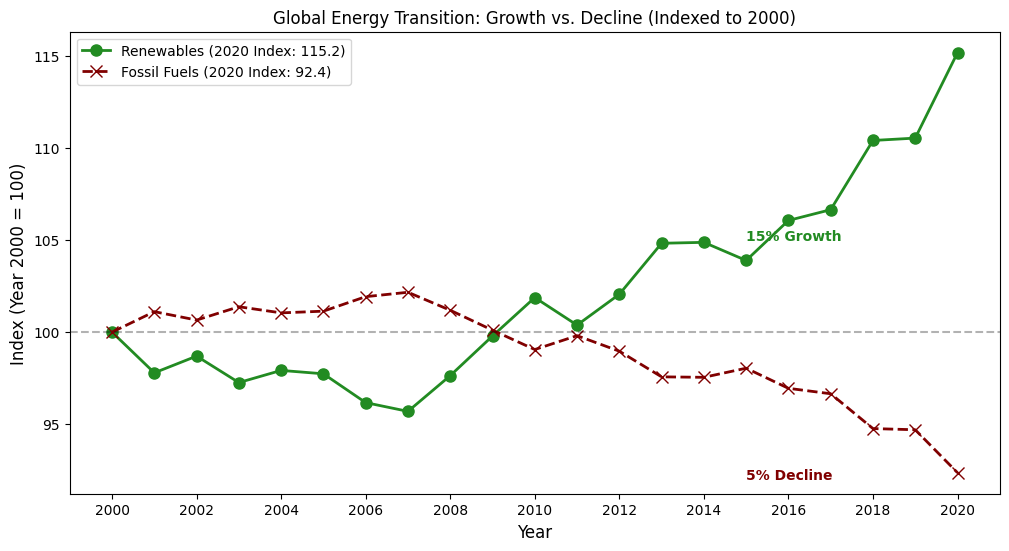

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))
# Plot Renewables with circle markers
plt.plot(renewable_index.index, renewable_index, label=f'Renewables (2020 Index: {renewable_index.iloc[-1]:.1f})', 
         color='forestgreen', marker='o', markersize=8, linewidth=2)

# Plot Fossil Fuels with 'x' markers
plt.plot(fossil_index.index, fossil_index, label=f'Fossil Fuels (2020 Index: {fossil_index.iloc[-1]:.1f})', 
         color='maroon', marker='x', markersize=8, linewidth=2, linestyle='--')
plt.axhline(100, color='black', linestyle='--', alpha=0.3) # The "No Change" line
plt.title('Global Energy Transition: Growth vs. Decline (Indexed to 2000)')
plt.ylabel('Index (Year 2000 = 100)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()

# This forces the X-axis to only use Integers (Whole Years)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Optional: Adding a text box to highlight the "Gap"
plt.text(2015, 105, '15% Growth', color='forestgreen', fontweight='bold')
plt.text(2015, 92, '5% Decline', color='maroon', fontweight='bold')
plt.xticks(np.arange(2000, 2021, 2))
plt.savefig('energy_transition_chart.png', dpi=300, bbox_inches='tight')
plt.show()

Key Insights & Findings

1. Steady Transition: Gradual slopes reflect the massive physical infrastructure and power grids required for energy transitions, showing incremental change rather than sudden spikes.
2. Turning Point: Prior to 2012, fossil fuel reliance held perfectly steady. Post-2012, renewable growth accelerated, marking a structural pivot from baseline expansion to active displacement.
3. Growth Reality: By 2020, a clear inverse relationship emerged. Renewables climbed by 15% while fossil fuels dropped by 5%, proving clean energy easily captures new demand but has not yet replaced existing baseline infrastructure.

## **Correlation Coefficient**  
This code block calculates the correlation coefficient between the global shares of renewables and fossil fuels to mathematically prove if renewables are actively displacing fossil fuels. A strong negative correlation (close to `-1`) will confirm that as clean energy adoption climbs, fossil fuel reliance is forced down in direct lockstep across the global timeline.

In [21]:
correlation = renewable_avg.corr(fossil_avg)
print(f"The Correlation Coefficient between Renewables and Fossil Fuels is: {correlation:.2f}")

The Correlation Coefficient between Renewables and Fossil Fuels is: -1.00


# Analysis Summary  

* Process: Calculated percentage shares from the raw power data, combined all countries into a single global average for each year, and forced both lines to start at `100` in the year 2000 to easily track relative growth.
* Insight: The data reveals 2012 as the true turning point. Before 2012, fossil fuel reliance stayed completely flat. After 2012, renewables sped up, moving from just growing to actively pushing fossil fuels out.
* Reality: By 2020, renewables grew by 15% while fossil fuels only dropped by 5%. This shows clean energy is growing three times faster to cover new power demands, but it has not yet fully replaced old, existing power grids.

# Future Analysis Plan  

Future analysis to be explore:  
1. Economic Analysis: Investigate whether aggressive shifts to clean energy correlate with changes in **GDP growth (annual %)** and **GDP per capita**.
2. Predictive Modelling: Leverage **Primary energy consumption per capita** to build machine learning models that forecast future global power demands.
3. Environmental Impact: Quantify the exact impact of changing the **Low-carbon electricity (% electricity)** share on reducing **Value_co2_emissions (metric tons per capita)**.
4. Demographic View: Examine how **Access to electricity (% of population)** and **Access to clean fuels for cooking`** change as a nation's **`Density (P/Km2)`** increases or as its green infrastructure expands.